In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) 
])

train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=128, shuffle=True)

print(f"Training samples: {len(train_dataset)}")

images, _ = next(iter(train_loader))
print(f"Image shape     : {images.shape}")
print(f"Pixel range     : {images.min():.1f} to {images.max():.1f}")

Device: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 17.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 477kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.52MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.2MB/s]


Training samples: 60000
Image shape     : torch.Size([128, 1, 28, 28])
Pixel range     : -1.0 to 1.0


In [2]:
LATENT_DIM = 100  

class Generator(nn.Module):
    def __init__(self, latent_dim):
        super(Generator, self).__init__()
        
        self.network = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(256),
            
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(512),
            
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(1024),
            
            nn.Linear(1024, 28 * 28),
            nn.Tanh()  
        )
    
    def forward(self, z):
        return self.network(z).view(-1, 1, 28, 28)  


class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        
        self.network = nn.Sequential(
            nn.Flatten(),
            
            nn.Linear(28 * 28, 1024),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            
            nn.Linear(256, 1),
            nn.Sigmoid()  
        )
    
    def forward(self, x):
        return self.network(x)


G = Generator(LATENT_DIM).to(device)
D = Discriminator().to(device)

print(f"Generator     params: {sum(p.numel() for p in G.parameters()):,}")
print(f"Discriminator params: {sum(p.numel() for p in D.parameters()):,}")

# Test
noise = torch.randn(4, LATENT_DIM).to(device)
fake  = G(noise)
pred  = D(fake)
print(f"\nNoise shape     : {noise.shape}")
print(f"Generated shape : {fake.shape}")
print(f"D prediction    : {pred.shape}")

Generator     params: 1,489,936
Discriminator params: 1,460,225

Noise shape     : torch.Size([4, 100])
Generated shape : torch.Size([4, 1, 28, 28])
D prediction    : torch.Size([4, 1])


In [3]:
criterion = nn.BCELoss()

optimizer_G = torch.optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = torch.optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))

real_label = 1.0
fake_label = 0.0

print("Criterion  : BCELoss")
print("Optimizer G: Adam lr=0.0002, betas=(0.5, 0.999)")
print("Optimizer D: Adam lr=0.0002, betas=(0.5, 0.999)")

Criterion  : BCELoss
Optimizer G: Adam lr=0.0002, betas=(0.5, 0.999)
Optimizer D: Adam lr=0.0002, betas=(0.5, 0.999)


Training GAN...
Epoch  10/50 | G Loss: 0.9382 | D Loss: 1.2489


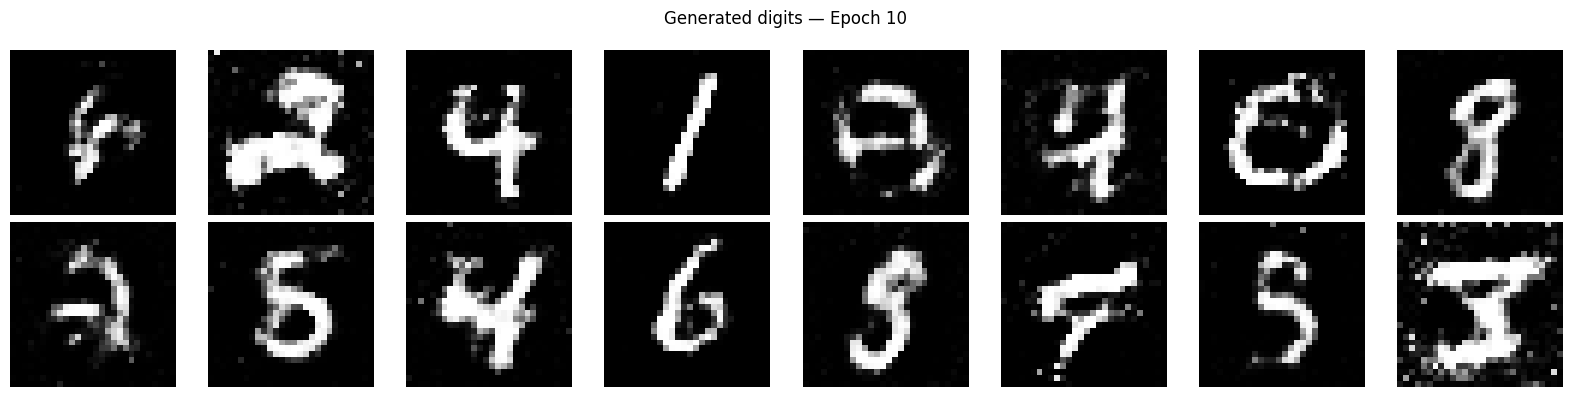

Epoch  20/50 | G Loss: 0.8399 | D Loss: 1.3094


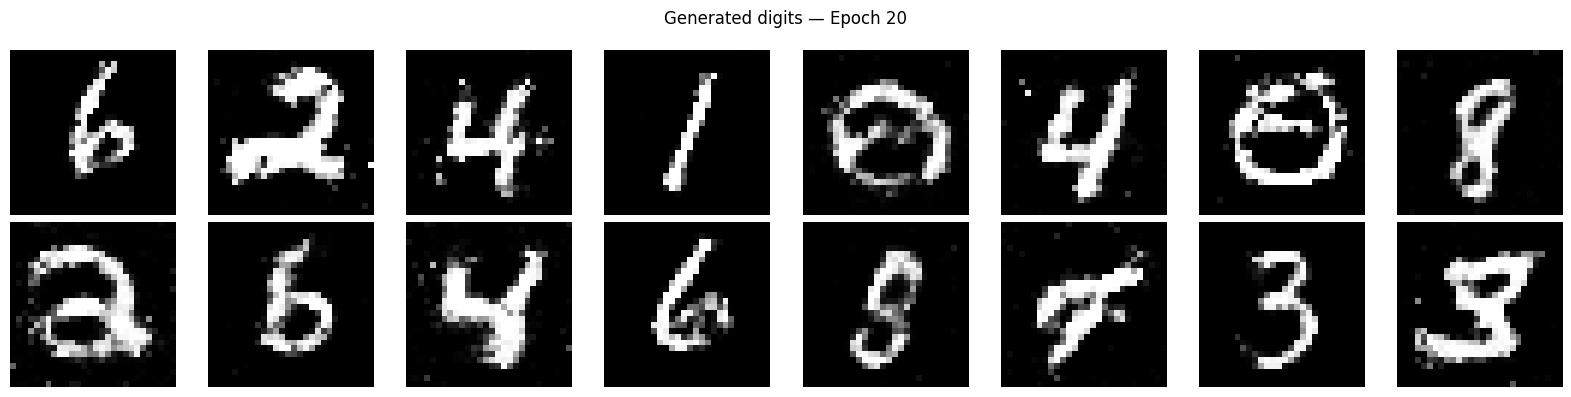

Epoch  30/50 | G Loss: 0.8180 | D Loss: 1.3188


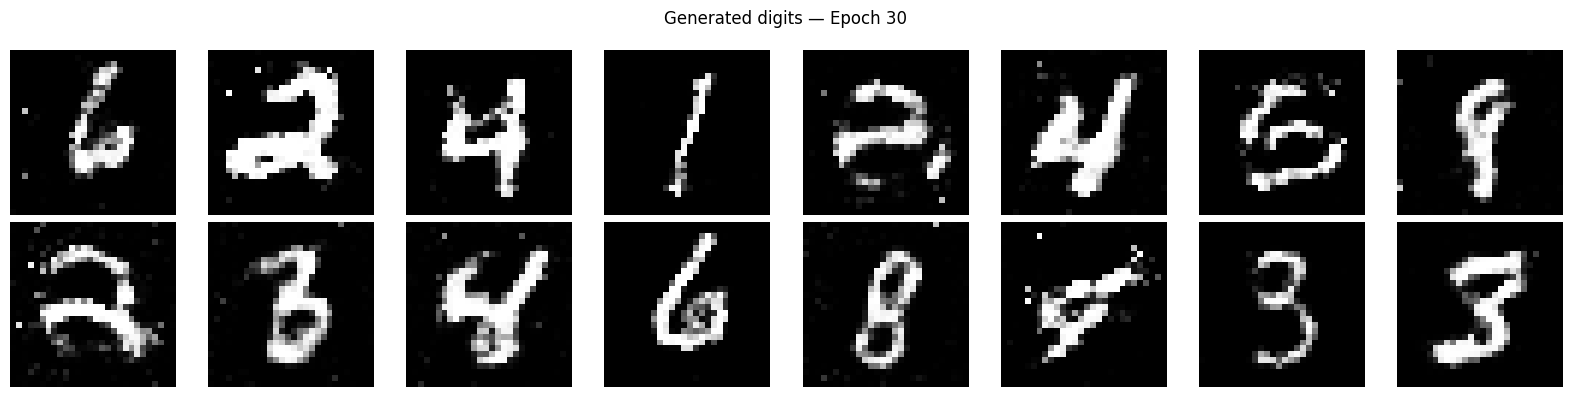

Epoch  40/50 | G Loss: 0.8178 | D Loss: 1.3200


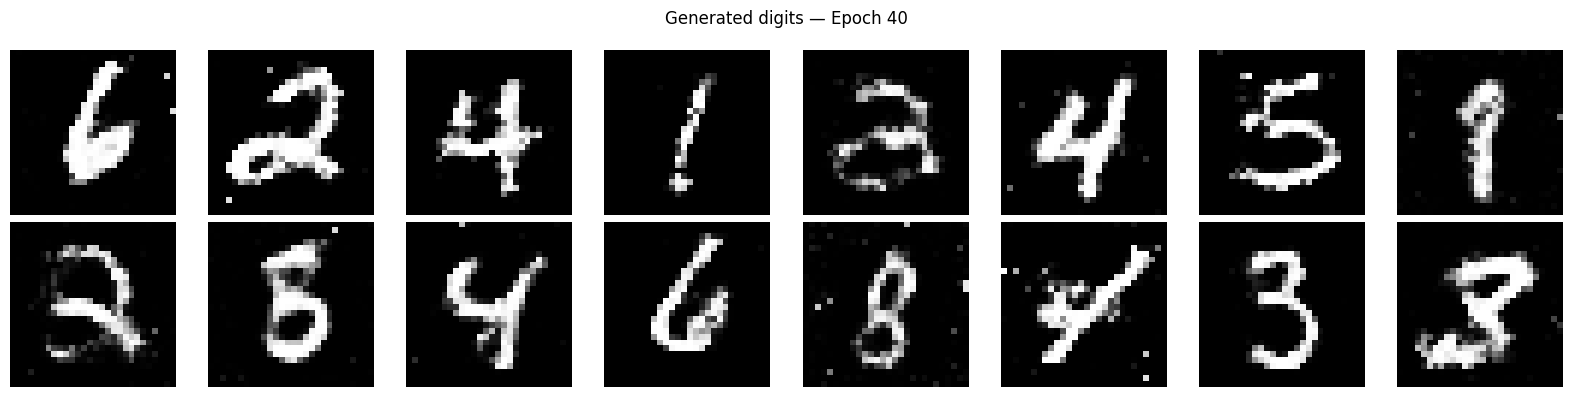

Epoch  50/50 | G Loss: 0.8178 | D Loss: 1.3196


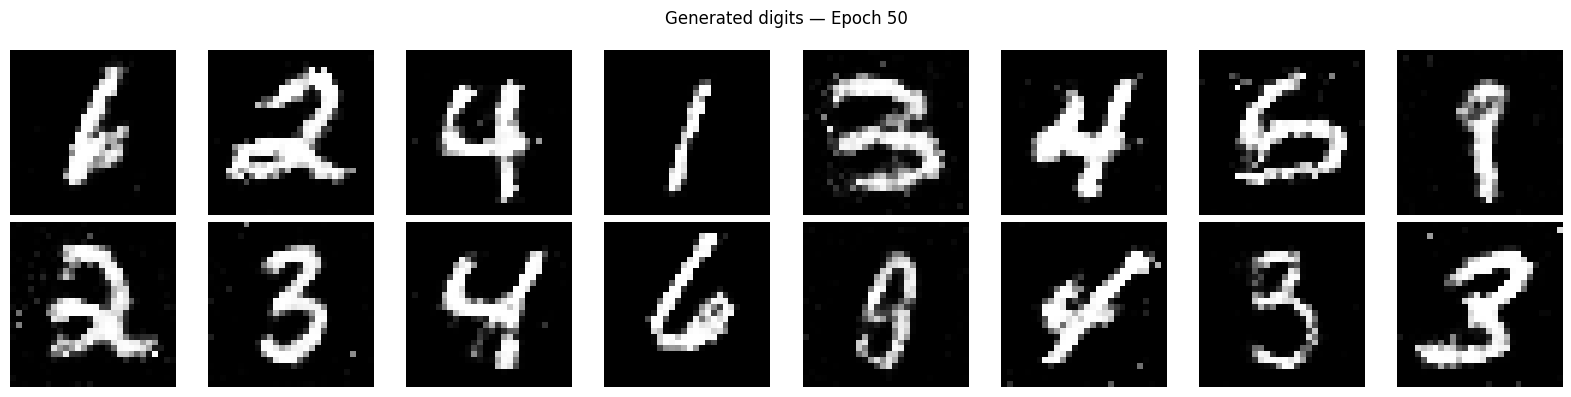


Training complete!


In [ ]:
n_epochs   = 50
G_losses   = []
D_losses   = []

fixed_noise = torch.randn(16, LATENT_DIM).to(device)

print("Training GAN...")
print("="*60)

for epoch in range(n_epochs):
    G_loss_epoch = 0
    D_loss_epoch = 0
    
    for real_images, _ in train_loader:
        batch_size  = real_images.size(0)
        real_images = real_images.to(device)
        
        optimizer_D.zero_grad()
        
        real_labels = torch.ones(batch_size, 1).to(device)
        real_output = D(real_images)
        D_loss_real = criterion(real_output, real_labels)
        
        noise       = torch.randn(batch_size, LATENT_DIM).to(device)
        fake_images = G(noise)
        fake_labels = torch.zeros(batch_size, 1).to(device)
        fake_output = D(fake_images.detach())  
        D_loss_fake = criterion(fake_output, fake_labels)
        
        D_loss = D_loss_real + D_loss_fake
        D_loss.backward()
        optimizer_D.step()
        

        optimizer_G.zero_grad()
        
        fake_output = D(fake_images)  
        G_loss      = criterion(fake_output, real_labels)  
        
        G_loss.backward()
        optimizer_G.step()
        
        G_loss_epoch += G_loss.item()
        D_loss_epoch += D_loss.item()
    
    G_losses.append(G_loss_epoch / len(train_loader))
    D_losses.append(D_loss_epoch / len(train_loader))
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{n_epochs} | "
              f"G Loss: {G_losses[-1]:.4f} | "
              f"D Loss: {D_losses[-1]:.4f}")
        
        G.eval()
        with torch.no_grad():
            fake = G(fixed_noise).cpu()
        G.train()
        
        fig, axes = plt.subplots(2, 8, figsize=(16, 4))
        axes = axes.flatten()
        for i in range(16):
            img = fake[i].squeeze() * 0.5 + 0.5
            axes[i].imshow(img, cmap='gray')
            axes[i].axis('off')
        plt.suptitle(f'Generated digits — Epoch {epoch+1}')
        plt.tight_layout()
        plt.show()

print("\nTraining complete!")

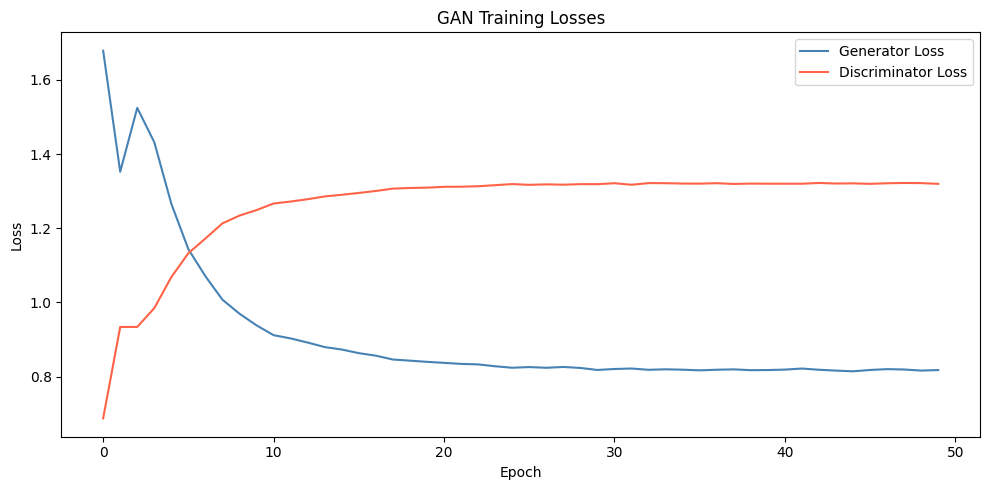

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(G_losses, label='Generator Loss', color='steelblue')
plt.plot(D_losses, label='Discriminator Loss', color='tomato')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('GAN Training Losses')
plt.legend()
plt.tight_layout()
plt.show()